Reinforcement Learning - Individual Assignment - Yurong Wen
---

## Assignment Goals
- Train and compare two RL agents on `TextFlappyBird-v0`
- Visualize learning curves and value functions
- Run parameter sweeps
- Test generalization to different environment configurations

In [ ]:
!pip install gymnasium numpy matplotlib pandas tqdm
!pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git
!pip install text-flappy-bird-gym

import importlib
import itertools
import random
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import trange

try:
    import gymnasium as gym
except ImportError:
    import gym  # fallback

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

  Cloning https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to /private/var/folders/ny/xvll83sn47lc3qn38651bj2h0000gn/T/pip-req-build-3c0jvlie
  Running command git clone --filter=blob:none --quiet https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git /private/var/folders/ny/xvll83sn47lc3qn38651bj2h0000gn/T/pip-req-build-3c0jvlie
  Resolved https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to commit ca2797e9270195313423324c9d0f205f6cbb3d28
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 9.2 MB/s  0:00:00
  Created wheel for text-flappy-bird-gym: filename=text_flappy_bird_gym-0.1.1-py3-none-any.whl size=7837 sha256=4ce7c832b109510fd08f92ee7b572fa9dce9e951254cc92a72c9d5cbe765195d
  Stored in directory: /private/var/folder

In [11]:
@dataclass
class EnvConfig:
    # Leave as None to auto-detect available Text Flappy Bird env ID.
    env_id: Optional[str] = None
    width: Optional[int] = None
    height: Optional[int] = None
    pipe_gap: Optional[int] = None


@dataclass
class TrainConfig:
    episodes: int = 5000
    eval_every: int = 250
    eval_episodes: int = 20
    gamma: float = 0.99
    epsilon_start: float = 0.2
    epsilon_end: float = 0.02
    epsilon_decay_fraction: float = 0.8
    max_steps_per_episode: int = 2000


@dataclass
class DiscretizerConfig:
    x_min: float = -20.0
    x_max: float = 20.0
    y_min: float = -20.0
    y_max: float = 20.0
    x_bins: int = 20
    y_bins: int = 20

In [12]:
class StateDiscretizer:
    """Discretizes (x, y) observation to a tabular state index."""

    def __init__(self, cfg: DiscretizerConfig):
        self.cfg = cfg
        self.x_edges = np.linspace(cfg.x_min, cfg.x_max, cfg.x_bins + 1)
        self.y_edges = np.linspace(cfg.y_min, cfg.y_max, cfg.y_bins + 1)

    def transform(self, obs) -> Tuple[int, int]:
        arr = np.asarray(obs, dtype=np.float32).reshape(-1)
        if arr.shape[0] < 2:
            raise ValueError(f"Expected observation with at least 2 values, got: {obs}")

        x, y = float(arr[0]), float(arr[1])
        x_idx = int(np.clip(np.digitize(x, self.x_edges) - 1, 0, self.cfg.x_bins - 1))
        y_idx = int(np.clip(np.digitize(y, self.y_edges) - 1, 0, self.cfg.y_bins - 1))
        return (x_idx, y_idx)


def linear_epsilon(episode: int, cfg: TrainConfig) -> float:
    decay_episodes = int(cfg.episodes * cfg.epsilon_decay_fraction)
    if episode >= decay_episodes:
        return cfg.epsilon_end
    frac = episode / max(1, decay_episodes)
    return cfg.epsilon_start + frac * (cfg.epsilon_end - cfg.epsilon_start)


def epsilon_greedy_action(q_values: Dict[Tuple[Tuple[int, int], int], float], state, n_actions: int, epsilon: float) -> int:
    if np.random.random() < epsilon:
        return int(np.random.randint(n_actions))

    action_values = [q_values[(state, a)] for a in range(n_actions)]
    max_q = np.max(action_values)
    best_actions = [a for a, q in enumerate(action_values) if q == max_q]
    return int(np.random.choice(best_actions))

In [13]:
class MonteCarloControlAgent:
    """On-policy first-visit Monte Carlo control."""

    def __init__(self, n_actions: int, gamma: float = 0.99):
        self.n_actions = n_actions
        self.gamma = gamma
        self.Q = defaultdict(float)
        self.returns_sum = defaultdict(float)
        self.returns_count = defaultdict(float)

    def act(self, state, epsilon: float = 0.0) -> int:
        return epsilon_greedy_action(self.Q, state, self.n_actions, epsilon)

    def update_episode(self, states: List[Tuple[int, int]], actions: List[int], rewards: List[float]):
        G = 0.0
        visited = set()

        for t in reversed(range(len(rewards))):
            G = self.gamma * G + rewards[t]
            sa = (states[t], actions[t])

            if sa in visited:
                continue
            visited.add(sa)

            self.returns_sum[sa] += G
            self.returns_count[sa] += 1.0
            self.Q[sa] = self.returns_sum[sa] / self.returns_count[sa]

In [14]:
class SarsaLambdaAgent:
    """Tabular Sarsa(lambda) with replacing traces."""

    def __init__(self, n_actions: int, alpha: float = 0.05, gamma: float = 0.99, lam: float = 0.9):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam

        self.Q = defaultdict(float)
        self.E = defaultdict(float)

    def act(self, state, epsilon: float = 0.0) -> int:
        return epsilon_greedy_action(self.Q, state, self.n_actions, epsilon)

    def reset_traces(self):
        self.E.clear()

    def update_step(self, s, a, r, s_next, a_next, done: bool):
        q_sa = self.Q[(s, a)]
        q_next = 0.0 if done else self.Q[(s_next, a_next)]
        delta = r + self.gamma * q_next - q_sa

        self.E[(s, a)] = 1.0

        # Update all eligibility-trace entries
        keys = list(self.E.keys())
        for key in keys:
            self.Q[key] += self.alpha * delta * self.E[key]
            if done:
                self.E[key] = 0.0
            else:
                self.E[key] *= self.gamma * self.lam

        # Keep dictionary compact
        for key in list(self.E.keys()):
            if abs(self.E[key]) < 1e-8:
                del self.E[key]

In [15]:
def _registered_env_ids():
    return sorted(spec.id for spec in gym.envs.registry.values())


def ensure_tfb_registered(preferred_id: Optional[str] = None) -> str:
    """Return a registered TFB env id or raise a clear installation error."""
    # Some third-party envs register only after import.
    for module_name in [
        "text_flappy_bird_gym",
        "text_flappy_bird",
        "textflappybird",
    ]:
        try:
            importlib.import_module(module_name)
        except Exception:
            pass

    ids = _registered_env_ids()

    if preferred_id and preferred_id in ids:
        return preferred_id

    # Prefer course-recommended default if present.
    if "TextFlappyBird-v0" in ids:
        return "TextFlappyBird-v0"

    flappy_like = [i for i in ids if "flappy" in i.lower() or "textflappy" in i.lower()]
    if flappy_like:
        return flappy_like[0]

    raise RuntimeError(
        "No Text Flappy Bird environment is registered. "
        "Install the package and restart kernel, for example:\n"
        "  pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git\n"
        "Then rerun the notebook from the top."
    )


def make_env(cfg: EnvConfig, seed: Optional[int] = None):
    kwargs = {}
    if cfg.width is not None:
        kwargs["width"] = cfg.width
    if cfg.height is not None:
        kwargs["height"] = cfg.height
    if cfg.pipe_gap is not None:
        kwargs["pipe_gap"] = cfg.pipe_gap

    env_id = ensure_tfb_registered(cfg.env_id)
    env = gym.make(env_id, **kwargs)

    # gymnasium reset API
    if seed is not None:
        try:
            env.reset(seed=seed)
        except TypeError:
            env.seed(seed)

    return env


def parse_reset(reset_out):
    if isinstance(reset_out, tuple) and len(reset_out) == 2:
        return reset_out[0]
    return reset_out


def parse_step(step_out):
    if len(step_out) == 5:
        obs, reward, terminated, truncated, info = step_out
        done = bool(terminated or truncated)
        return obs, reward, done, info
    obs, reward, done, info = step_out
    return obs, reward, bool(done), info

In [16]:
def train_agent(
    agent,
    env_cfg: EnvConfig,
    disc: StateDiscretizer,
    train_cfg: TrainConfig,
    seed: int = 42,
    algorithm: str = "mc",
):
    env = make_env(env_cfg, seed=seed)

    train_returns = []
    eval_returns = []
    eval_episodes_idx = []

    for ep in trange(train_cfg.episodes, desc=f"Training {algorithm}"):
        epsilon = linear_epsilon(ep, train_cfg)

        obs = parse_reset(env.reset())
        s = disc.transform(obs)

        ep_states, ep_actions, ep_rewards = [], [], []
        total_reward = 0.0

        if algorithm == "sarsa_lambda":
            agent.reset_traces()
            a = agent.act(s, epsilon=epsilon)

        for _ in range(train_cfg.max_steps_per_episode):
            if algorithm == "mc":
                a = agent.act(s, epsilon=epsilon)

            next_obs, r, done, _ = parse_step(env.step(a))
            s_next = disc.transform(next_obs)

            total_reward += float(r)

            if algorithm == "mc":
                ep_states.append(s)
                ep_actions.append(a)
                ep_rewards.append(float(r))
            else:
                a_next = agent.act(s_next, epsilon=epsilon)
                agent.update_step(s, a, float(r), s_next, a_next, done)
                a = a_next

            s = s_next
            if done:
                break

        if algorithm == "mc":
            agent.update_episode(ep_states, ep_actions, ep_rewards)

        train_returns.append(total_reward)

        if (ep + 1) % train_cfg.eval_every == 0:
            m = evaluate_agent(agent, env_cfg, disc, episodes=train_cfg.eval_episodes, seed=seed + ep)
            eval_returns.append(m)
            eval_episodes_idx.append(ep + 1)

    env.close()

    return {
        "train_returns": np.array(train_returns),
        "eval_returns": np.array(eval_returns),
        "eval_episodes": np.array(eval_episodes_idx),
        "Q": agent.Q,
    }

In [17]:
def evaluate_agent(agent, env_cfg: EnvConfig, disc: StateDiscretizer, episodes: int = 20, seed: int = 123):
    env = make_env(env_cfg, seed=seed)
    returns = []

    for ep in range(episodes):
        obs = parse_reset(env.reset(seed=seed + ep) if hasattr(env, "reset") else env.reset())
        s = disc.transform(obs)
        total_reward = 0.0

        for _ in range(4000):
            a = agent.act(s, epsilon=0.0)
            next_obs, r, done, _ = parse_step(env.step(a))
            s = disc.transform(next_obs)
            total_reward += float(r)
            if done:
                break

        returns.append(total_reward)

    env.close()
    return float(np.mean(returns))


def moving_average(x, w=100):
    x = np.asarray(x)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")


def plot_learning_curves(mc_result, sarsa_result, ma_window=100):
    plt.figure(figsize=(11, 4))

    plt.subplot(1, 2, 1)
    mc_ma = moving_average(mc_result["train_returns"], ma_window)
    sa_ma = moving_average(sarsa_result["train_returns"], ma_window)
    plt.plot(mc_ma, label="MC (train MA)")
    plt.plot(sa_ma, label="Sarsa(lambda) (train MA)")
    plt.title("Training Returns")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(mc_result["eval_episodes"], mc_result["eval_returns"], marker="o", label="MC eval")
    plt.plot(sarsa_result["eval_episodes"], sarsa_result["eval_returns"], marker="o", label="Sarsa(lambda) eval")
    plt.title("Evaluation Returns")
    plt.xlabel("Episode")
    plt.ylabel("Mean return")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def q_to_v_surface(q_dict, x_bins: int, y_bins: int, n_actions: int):
    V = np.zeros((x_bins, y_bins), dtype=np.float32)
    for i in range(x_bins):
        for j in range(y_bins):
            V[i, j] = max(q_dict[((i, j), a)] for a in range(n_actions))
    return V


def plot_value_surface(q_dict, disc_cfg: DiscretizerConfig, n_actions: int, title: str):
    V = q_to_v_surface(q_dict, disc_cfg.x_bins, disc_cfg.y_bins, n_actions)
    plt.figure(figsize=(6, 5))
    plt.imshow(V.T, origin="lower", aspect="auto")
    plt.colorbar(label="V(s)=max_a Q(s,a)")
    plt.xlabel("x bin")
    plt.ylabel("y bin")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 1) Configure experiment and smoke test environment

In [18]:
env_cfg = EnvConfig(
    env_id=None,  # auto-detect; set explicit ID if needed
    width=20,
    height=15,
    pipe_gap=4,
)

train_cfg = TrainConfig(
    episodes=4000,
    eval_every=200,
    eval_episodes=20,
    gamma=0.99,
    epsilon_start=0.2,
    epsilon_end=0.02,
    epsilon_decay_fraction=0.8,
)

disc_cfg = DiscretizerConfig(
    x_min=-20,
    x_max=20,
    y_min=-20,
    y_max=20,
    x_bins=20,
    y_bins=20,
)

disc = StateDiscretizer(disc_cfg)

# Smoke test
resolved_env_id = ensure_tfb_registered(env_cfg.env_id)
print("Using env id:", resolved_env_id)

env = make_env(env_cfg, seed=SEED)
obs = parse_reset(env.reset())
print("Initial observation:", obs)
print("Discretized:", disc.transform(obs))
print("Action space n:", env.action_space.n)
env.close()

Using env id: TextFlappyBird-v0
Initial observation: (13, 4)
Discretized: (16, 12)
Action space n: 2


## 2) Train Monte Carlo and Sarsa(lambda) (single run each)

Training mc:   0%|          | 0/4000 [00:00<?, ?it/s]

Training sarsa_lambda:   0%|          | 0/4000 [00:00<?, ?it/s]

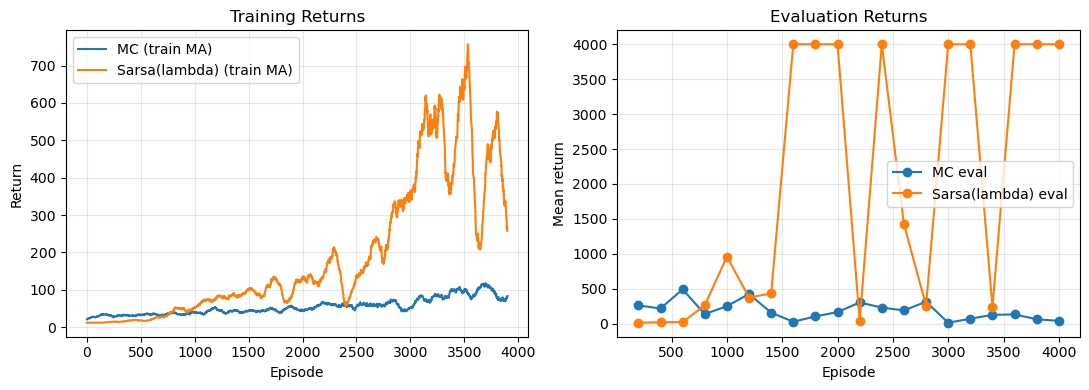

Final MC eval: 40.35
Final Sarsa(lambda) eval: 4000.0


In [19]:
n_actions = 2  # Text Flappy Bird typically uses 2 actions: do nothing / flap

mc_agent = MonteCarloControlAgent(n_actions=n_actions, gamma=train_cfg.gamma)
mc_result = train_agent(
    mc_agent,
    env_cfg=env_cfg,
    disc=disc,
    train_cfg=train_cfg,
    seed=SEED,
    algorithm="mc",
)

sarsa_agent = SarsaLambdaAgent(
    n_actions=n_actions,
    alpha=0.05,
    gamma=train_cfg.gamma,
    lam=0.9,
)
sarsa_result = train_agent(
    sarsa_agent,
    env_cfg=env_cfg,
    disc=disc,
    train_cfg=train_cfg,
    seed=SEED,
    algorithm="sarsa_lambda",
)

plot_learning_curves(mc_result, sarsa_result, ma_window=100)
print("Final MC eval:", mc_result["eval_returns"][-1] if len(mc_result["eval_returns"]) else "n/a")
print("Final Sarsa(lambda) eval:", sarsa_result["eval_returns"][-1] if len(sarsa_result["eval_returns"]) else "n/a")

## 3) State-value visualizations (derived from Q)

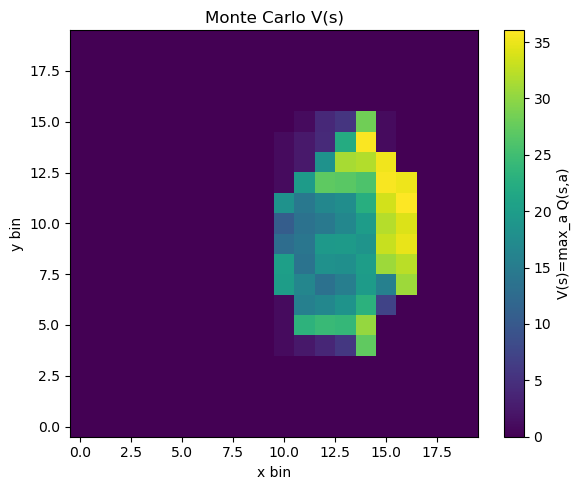

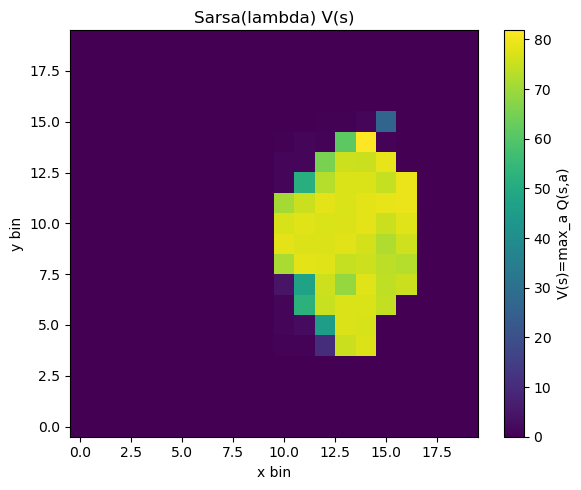

In [20]:
plot_value_surface(mc_result["Q"], disc_cfg, n_actions=n_actions, title="Monte Carlo V(s)")
plot_value_surface(sarsa_result["Q"], disc_cfg, n_actions=n_actions, title="Sarsa(lambda) V(s)")

## 4) Parameter sweeps

In [21]:
def run_mc_sweep(env_cfg, disc, base_train_cfg, gamma_values, epsilon_starts, seeds=(0, 1, 2)):
    rows = []
    for gamma, eps0 in itertools.product(gamma_values, epsilon_starts):
        scores = []
        for sd in seeds:
            cfg = TrainConfig(**{**base_train_cfg.__dict__, "gamma": gamma, "epsilon_start": eps0})
            agent = MonteCarloControlAgent(n_actions=2, gamma=cfg.gamma)
            result = train_agent(agent, env_cfg, disc, cfg, seed=sd, algorithm="mc")
            score = result["eval_returns"][-1] if len(result["eval_returns"]) else np.nan
            scores.append(score)
        rows.append(
            {
                "algorithm": "MC",
                "gamma": gamma,
                "epsilon_start": eps0,
                "mean_final_eval": float(np.nanmean(scores)),
                "std_final_eval": float(np.nanstd(scores)),
            }
        )
    return pd.DataFrame(rows)


def run_sarsa_sweep(env_cfg, disc, base_train_cfg, alpha_values, lambda_values, seeds=(0, 1, 2)):
    rows = []
    for alpha, lam in itertools.product(alpha_values, lambda_values):
        scores = []
        for sd in seeds:
            cfg = TrainConfig(**base_train_cfg.__dict__)
            agent = SarsaLambdaAgent(n_actions=2, alpha=alpha, gamma=cfg.gamma, lam=lam)
            result = train_agent(agent, env_cfg, disc, cfg, seed=sd, algorithm="sarsa_lambda")
            score = result["eval_returns"][-1] if len(result["eval_returns"]) else np.nan
            scores.append(score)
        rows.append(
            {
                "algorithm": "Sarsa(lambda)",
                "alpha": alpha,
                "lambda": lam,
                "mean_final_eval": float(np.nanmean(scores)),
                "std_final_eval": float(np.nanstd(scores)),
            }
        )
    return pd.DataFrame(rows)

In [22]:
# Keep sweeps modest first; increase if you have time/compute.
sweep_train_cfg = TrainConfig(
    episodes=2000,
    eval_every=200,
    eval_episodes=10,
    gamma=0.99,
    epsilon_start=0.2,
    epsilon_end=0.02,
    epsilon_decay_fraction=0.8,
)

mc_sweep_df = run_mc_sweep(
    env_cfg,
    disc,
    sweep_train_cfg,
    gamma_values=[0.95, 0.99],
    epsilon_starts=[0.1, 0.2],
    seeds=(0, 1, 2),
)

sarsa_sweep_df = run_sarsa_sweep(
    env_cfg,
    disc,
    sweep_train_cfg,
    alpha_values=[0.01, 0.05, 0.1],
    lambda_values=[0.0, 0.5, 0.9],
    seeds=(0, 1, 2),
)

display(mc_sweep_df.sort_values("mean_final_eval", ascending=False))
display(sarsa_sweep_df.sort_values("mean_final_eval", ascending=False))

Training mc:   0%|          | 0/2000 [00:00<?, ?it/s]

Training mc:   0%|          | 0/2000 [00:00<?, ?it/s]

Training mc:   0%|          | 0/2000 [00:00<?, ?it/s]

Training mc:   0%|          | 0/2000 [00:00<?, ?it/s]

Training mc:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Training sarsa_lambda:   0%|          | 0/2000 [00:00<?, ?it/s]

Training sarsa_lambda:   0%|          | 0/2000 [00:00<?, ?it/s]

Training sarsa_lambda:   0%|          | 0/2000 [00:00<?, ?it/s]

,algorithm,gamma,epsilon_start,mean_final_eval,std_final_eval
1,MC,0.95,0.2,1458.100000,1797.563301
0,MC,0.95,0.1,140.666667,79.754136
2,MC,0.99,0.1,129.000000,74.190610
3,MC,0.99,0.2,75.800000,52.894675


,algorithm,alpha,lambda,mean_final_eval,std_final_eval
7,Sarsa(lambda),0.10,0.5,2902.666667,1551.863682
4,Sarsa(lambda),0.05,0.5,1017.300000,1418.883683
8,Sarsa(lambda),0.10,0.9,581.266667,112.399565
6,Sarsa(lambda),0.10,0.0,430.366667,417.009595
5,Sarsa(lambda),0.05,0.9,83.000000,64.315058
3,Sarsa(lambda),0.05,0.0,35.966667,14.872869
2,Sarsa(lambda),0.01,0.9,12.833333,5.216853
0,Sarsa(lambda),0.01,0.0,12.566667,0.731817
1,Sarsa(lambda),0.01,0.5,10.700000,1.606238


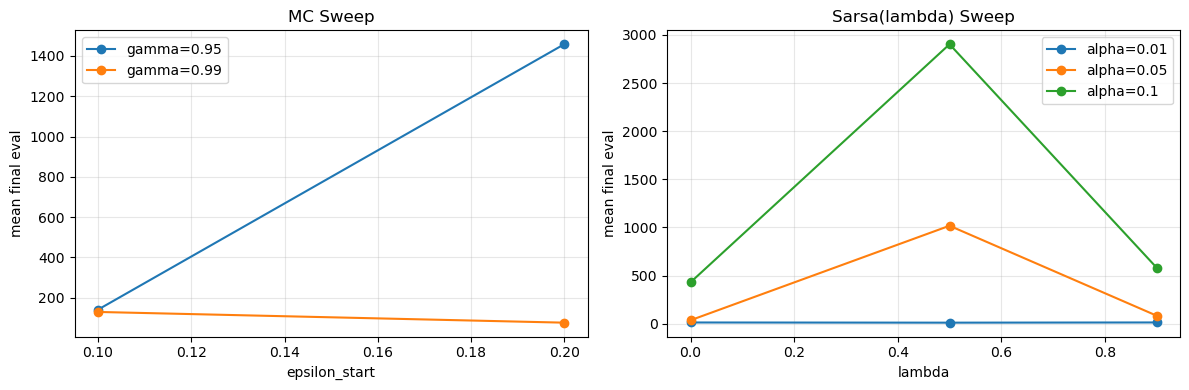

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for g in sorted(mc_sweep_df["gamma"].unique()):
    tmp = mc_sweep_df[mc_sweep_df["gamma"] == g].sort_values("epsilon_start")
    plt.plot(tmp["epsilon_start"], tmp["mean_final_eval"], marker="o", label=f"gamma={g}")
plt.title("MC Sweep")
plt.xlabel("epsilon_start")
plt.ylabel("mean final eval")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
for a in sorted(sarsa_sweep_df["alpha"].unique()):
    tmp = sarsa_sweep_df[sarsa_sweep_df["alpha"] == a].sort_values("lambda")
    plt.plot(tmp["lambda"], tmp["mean_final_eval"], marker="o", label=f"alpha={a}")
plt.title("Sarsa(lambda) Sweep")
plt.xlabel("lambda")
plt.ylabel("mean final eval")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 5) Generalization test across level configurations

In [24]:
def evaluate_on_multiple_envs(agent, disc, env_cfgs, episodes=30):
    rows = []
    for cfg in env_cfgs:
        score = evaluate_agent(agent, cfg, disc, episodes=episodes, seed=123)
        rows.append(
            {
                "env_id": cfg.env_id,
                "width": cfg.width,
                "height": cfg.height,
                "pipe_gap": cfg.pipe_gap,
                "mean_eval_return": score,
            }
        )
    return pd.DataFrame(rows)


test_env_cfgs = [
    EnvConfig(env_id="TextFlappyBird-v0", width=20, height=15, pipe_gap=4),  # train-like
    EnvConfig(env_id="TextFlappyBird-v0", width=24, height=15, pipe_gap=4),
    EnvConfig(env_id="TextFlappyBird-v0", width=20, height=18, pipe_gap=4),
    EnvConfig(env_id="TextFlappyBird-v0", width=20, height=15, pipe_gap=5),
]

mc_gen_df = evaluate_on_multiple_envs(mc_agent, disc, test_env_cfgs, episodes=30)
sarsa_gen_df = evaluate_on_multiple_envs(sarsa_agent, disc, test_env_cfgs, episodes=30)

print("Monte Carlo generalization")
display(mc_gen_df)
print("Sarsa(lambda) generalization")
display(sarsa_gen_df)

Monte Carlo generalization


,env_id,width,height,pipe_gap,mean_eval_return
0,TextFlappyBird-v0,20,15,4,42.200000
1,TextFlappyBird-v0,24,15,4,34.166667
2,TextFlappyBird-v0,20,18,4,47.966667
3,TextFlappyBird-v0,20,15,5,231.700000


Sarsa(lambda) generalization


,env_id,width,height,pipe_gap,mean_eval_return
0,TextFlappyBird-v0,20,15,4,4000.000000
1,TextFlappyBird-v0,24,15,4,226.600000
2,TextFlappyBird-v0,20,18,4,299.533333
3,TextFlappyBird-v0,20,15,5,4000.000000
